<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Deep%20Learning/Autoencoders/Convolucional_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow==2.16.1

In [54]:
import tensorflow as tf
import pandas as pd
import matplotlib

In [55]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model, Sequential
import matplotlib.pyplot as plt
from tensorflow.keras.layers import InputLayer, Dense, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Reshape

In [56]:
(X_treinamento, _), (X_test, _) = mnist.load_data()

In [57]:
X_treinamento = X_treinamento.reshape(len(X_treinamento), 28, 28, 1)
X_test = X_test.reshape(len(X_test), 28, 28, 1)

In [58]:
X_treinamento = X_treinamento.astype("float32") / 255
X_test = X_test.astype("float32") / 255

In [59]:
autoencoder = Sequential()

# Codificador
autoencoder.add(InputLayer(shape = (28, 28, 1)))
autoencoder.add(Conv2D(filters = 16, kernel_size = (3,3), activation='relu'))
autoencoder.add(MaxPooling2D(pool_size = (2,2)))
autoencoder.add(Conv2D(filters = 8, kernel_size = (3,3), activation='relu', padding='same'))
autoencoder.add(MaxPooling2D(pool_size = (2,2), padding='same'))
autoencoder.add(Conv2D(filters = 8, kernel_size = (3,3), activation='relu', padding='same', strides=(2,2)))
autoencoder.add(Flatten())

# Decodificador
autoencoder.add(Reshape((4, 4, 8)))
autoencoder.add(Conv2D(filters = 8, kernel_size = (3,3), activation='relu', padding='same'))
autoencoder.add(UpSampling2D(size = (2,2)))
autoencoder.add(Conv2D(filters = 8, kernel_size = (3,3), activation='relu', padding='same'))
autoencoder.add(UpSampling2D(size = (2,2)))
autoencoder.add(Conv2D(filters = 16, kernel_size = (3,3), activation='relu'))
autoencoder.add(UpSampling2D(size = (2,2)))
autoencoder.add(Conv2D(filters = 1, kernel_size = (3,3), activation='sigmoid', padding='same'))

autoencoder.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_119 (Conv2D)             │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_120 (Conv2D)             │ (None, 13, 13, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_121 (Conv2D)             │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_13 (Reshape)            │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_122 (Conv2D)             │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_33 (UpSampling2D) │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_123 (Conv2D)             │ (None, 8, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_34 (UpSampling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_124 (Conv2D)             │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_35 (UpSampling2D) │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_125 (Conv2D)             │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
autoencoder.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])
autoencoder.fit(X_treinamento, X_treinamento, epochs = 10, batch_size = 256, validation_data = (X_test, X_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 78s 297ms/step - accuracy: 0.7686 - loss: 0.4090 - val_accuracy: 0.7962 - val_loss: 0.1598
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 77s 278ms/step - accuracy: 0.7994 - loss: 0.1511 - val_accuracy: 0.8062 - val_loss: 0.1296
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 279ms/step - accuracy: 0.8064 - loss: 0.1268 - val_accuracy: 0.8083 - val_loss: 0.1181
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 81s 275ms/step - accuracy: 0.8087 - loss: 0.1174 - val_accuracy: 0.8100 - val_loss: 0.1127
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 66s 280ms/step - accuracy: 0.8101 - loss: 0.1120 - val_accuracy: 0.8099 - val_loss: 0.1080
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 65s 277ms/step - accuracy: 0.8104 - loss: 0.1085 - val_accuracy: 0.8100 - val_loss: 0.1049
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 91s 315ms/step - accuracy: 0.8111 - loss: 0.1056 - val_accuracy: 0.8104 - val_loss: 0.1027
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 73s 275ms/step - accuracy: 0.8115 - loss: 0

In [62]:
encoder = Model(inputs = autoencoder.get_layer("conv2d_119").input, outputs = autoencoder.get_layer("flatten_21").output)

In [63]:
imagens_codificadas = encoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [64]:
imagens_codificadas.shape

(10000, 128)

In [65]:
imagens_decodificadas = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [66]:
imagens_decodificadas.shape

(10000, 28, 28, 1)

In [67]:
import numpy as np

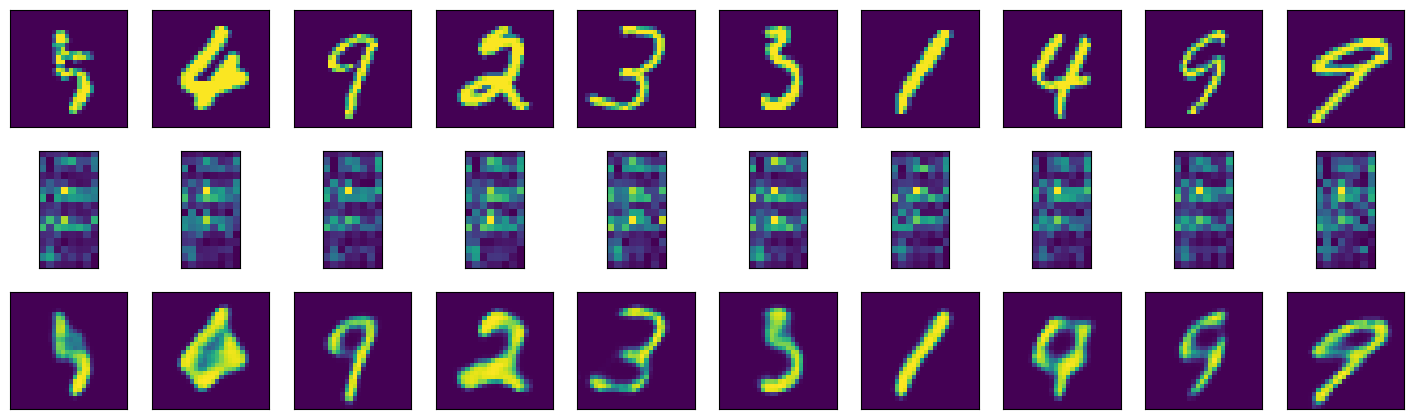

In [68]:
numero_imagens = 10
imagens_teste = np.random.randint(X_test.shape[0], size=numero_imagens)
plt.figure(figsize=(18,18))
for i, indice_imagem in enumerate(imagens_teste):
    # imagem original
    eixo = plt.subplot(10, 10, i + 1)
    plt.imshow(X_test[indice_imagem].reshape(28, 28))
    plt.xticks(())
    plt.yticks(())

    # imagem codificada
    eixo = plt.subplot(10, 10, i + 1 + numero_imagens)
    plt.imshow(imagens_codificadas[indice_imagem].reshape(16, 8))
    plt.xticks(())
    plt.yticks(())

     # imagem reconstruída
    eixo = plt.subplot(10, 10, i + 1 + numero_imagens * 2)
    plt.imshow(imagens_decodificadas[indice_imagem].reshape(28, 28))
    plt.xticks(())
    plt.yticks(())